In [10]:
import pandas as pd
import numpy as np
import spacy
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

import os
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [3]:
df = pd.read_csv('../data/comentarios_toxicos_ptBR.csv')
df.dropna(subset=['text', 'toxic'], inplace=True)
df.head()

,Unnamed: 0,text,text_norm,toxic
0,12451,brocolis é muito boooom pqp,brócolis boom puta pariu,0
1,4080,to correndo disso,to correndo disso,0
2,5195,presidente da oab sofre amea莽as de morte e aci...,presidente aba sofre ame-a morte aciona polega...,0
3,13375,@user @user aí desanima pq para de vir teus ch...,aí desanima porque vir champ chato pra caralho...,1
4,4130,"ser feio e beta é um bosta, puta que me pariu....",feio beta bosta puta pariu lá vou comprar ócul...,1


In [4]:
nlp = spacy.load("pt_core_news_sm")

def preProcessar(texto):
    texto = str(texto).lower()
    texto = re.sub(r'[^a-záéíóúâêôãõüç\s]', '', texto)
    doc = nlp(texto)
    return [token.text for token in doc if not token.is_stop and token.text.strip()]

print("Processando textos (isso pode demorar alguns minutos)...")
if 'text_norm' in df.columns:
    df.dropna(subset=['text_norm'], inplace=True)
    df['text_normalized'] = df['text_norm'].apply(lambda x: x.split())
else:
    df['text_normalized'] = df['text'].apply(preProcessar)

df['text_normalized_str'] = df['text_normalized'].apply(lambda x: ' '.join(x))
df[['text', 'text_normalized_str', 'toxic']].head()

Processando textos (isso pode demorar alguns minutos)...


,text,text_normalized_str,toxic
0,brocolis é muito boooom pqp,brócolis boom puta pariu,0
1,to correndo disso,to correndo disso,0
2,presidente da oab sofre amea莽as de morte e aci...,presidente aba sofre ame-a morte aciona polega...,0
3,@user @user aí desanima pq para de vir teus ch...,aí desanima porque vir champ chato pra caralho...,1
4,"ser feio e beta é um bosta, puta que me pariu....",feio beta bosta puta pariu lá vou comprar ócul...,1


In [5]:
X = df['text_normalized_str']
y = df['toxic']

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=42, stratify=y_train_full
)

print("Treino:", len(X_train))
print("Validação:", len(X_val))
print("Teste:", len(X_test))

Treino: 21578
Validação: 3809
Teste: 4481


In [6]:
MAX_WORDS = 20000

tokenizer_nn = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer_nn.fit_on_texts(X_train)

print("Tamanho do vocabulário:", len(tokenizer_nn.word_index))

Tamanho do vocabulário: 38194


In [7]:
MAX_LEN = 100

X_train_seq = tokenizer_nn.texts_to_sequences(X_train)
X_val_seq = tokenizer_nn.texts_to_sequences(X_val)
X_test_seq = tokenizer_nn.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

y_train = np.array(y_train)
y_val = np.array(y_val)
y_test = np.array(y_test)

In [8]:
vocab_size = min(MAX_WORDS, len(tokenizer_nn.word_index) + 1)

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=MAX_LEN),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.summary()

c:\Users\Arthur Melo\toxic-comment-detector\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

os.makedirs('../models', exist_ok=True)
checkpoint = ModelCheckpoint(
    '../models/cnn_toxic_comments.keras',
    monitor='val_loss',
    save_best_only=True
)

In [12]:
history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=15,
    batch_size=64,
    callbacks=[early_stopping, checkpoint],
    verbose=1
)

Epoch 1/15
338/338 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.7419 - loss: 0.5153 - val_accuracy: 0.7816 - val_loss: 0.4347
Epoch 2/15
338/338 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.8435 - loss: 0.3444 - val_accuracy: 0.7695 - val_loss: 0.4748
Epoch 3/15
338/338 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.9065 - loss: 0.2180 - val_accuracy: 0.7577 - val_loss: 0.5756
Epoch 4/15
338/338 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.9487 - loss: 0.1275 - val_accuracy: 0.7593 - val_loss: 0.7350


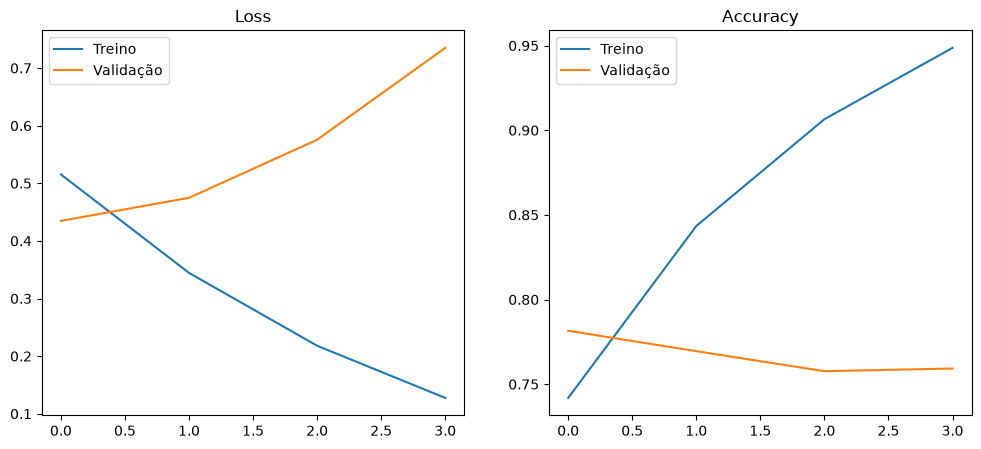

In [13]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Accuracy')
plt.legend()

plt.show()

In [14]:
results = model.evaluate(X_test_pad, y_test, verbose=1)
for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")

141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7878 - loss: 0.4301
loss: 0.4301
compile_metrics: 0.7878


              precision    recall  f1-score   support

  Não Tóxico       0.87      0.72      0.79      2455
      Tóxico       0.72      0.87      0.79      2026

    accuracy                           0.79      4481
   macro avg       0.79      0.79      0.79      4481
weighted avg       0.80      0.79      0.79      4481



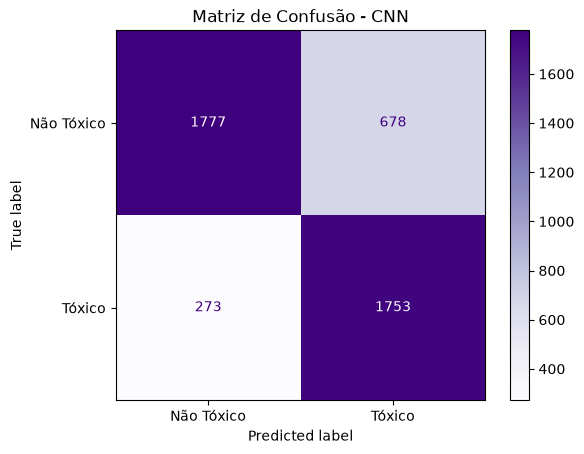

In [15]:
y_prob = model.predict(X_test_pad, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=['Não Tóxico', 'Tóxico']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Não Tóxico', 'Tóxico'])
disp.plot(cmap=plt.cm.Purples)
plt.title('Matriz de Confusão - CNN')
plt.show()

In [16]:
def previsao(text, threshold=0.5):
    # Pré-processamento
    tokens = preProcessar(text)
    
    # Transformar em sequência
    sequence = tokenizer_nn.texts_to_sequences([' '.join(tokens)])
    
    # Padding
    padded = pad_sequences(sequence, maxlen=MAX_LEN, padding='post', truncating='post')
    
    # Probabilidade
    probability = model.predict(padded, verbose=0)[0][0]
    
    # Classificação
    prediction = int(probability >= threshold)
    
    return prediction, probability

In [17]:
testes = [
    "Você é um idiota!",
    "Eu gostei muito desse vídeo.",
    "Que coisa maravilhosa!",
    "Esse cara é muito burro.",
    "Não concordo com você.",
    "Vai tomar no cu."
]

for texto in testes:
    resultado, probabilidade = previsao(texto)
    classe = "Tóxico" if resultado == 1 else "Não Tóxico"
    print(f"Texto: '{texto}' | Previsão: {classe} | Prob(Tóxico): {probabilidade:.2%}")

Texto: 'Você é um idiota!' | Previsão: Tóxico | Prob(Tóxico): 70.31%
Texto: 'Eu gostei muito desse vídeo.' | Previsão: Não Tóxico | Prob(Tóxico): 5.31%
Texto: 'Que coisa maravilhosa!' | Previsão: Não Tóxico | Prob(Tóxico): 5.18%
Texto: 'Esse cara é muito burro.' | Previsão: Tóxico | Prob(Tóxico): 87.02%
Texto: 'Não concordo com você.' | Previsão: Não Tóxico | Prob(Tóxico): 10.64%
Texto: 'Vai tomar no cu.' | Previsão: Tóxico | Prob(Tóxico): 92.17%
